# Action potential waveforms are state-dependent
### 3. Neurons show multimodal within-cell spike waveform spontaneous variability

Martin-Burgos, B., Juavinett, A., Riviere, P., Hammonds, R., & Voytek, B. (2026). *Action potential waveforms are state-dependent*. bioRxiv. https://www.biorxiv.org/content/10.64898/2026.09.15.751814v1

In Finding 2, spike shape changed with the current injected into a neuron. Here we ask whether spike shape also varies within a neuron when nobody is controlling its input, during spontaneous activity in an intact brain. If it does, a single neuron does not produce one fixed spike: it can switch between distinct "flavors" of spike over the course of a recording.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys

sys.path.append('finding_notebooks_functions/')
from finding3_functions import (load_cluster_data, print_cluster_summary,
                                plot_fig4b, plot_fig4c, cluster_report_explorer)

# all data used here ships with the repo (see finding_notebooks_data/build_finding3_data.py)
DATA_DIR = 'finding_notebooks_data/finding3/'
data = load_cluster_data(DATA_DIR)

## The spe-1 dataset

spe-1 (Marques-Smith et al., 2020; CRCNS) contains simultaneous recordings from single neurons in the motor and somatosensory cortex of anesthetized rats: a patch pipette records each neuron's intracellular action potentials while a Neuropixels probe next to it records the extracellular spikes and the local field potential (LFP). The neurons were firing spontaneously, without any experimenter-controlled stimulation. Of the 43 recorded neurons, 40 had enough spikes for the analyses below. Notebook 5, which uses the LFP, describes the dataset in full.

We ran `spikewise` on every intracellular spike from each neuron, giving the same features introduced in Finding 1 (ramp, peak and repolarization features, plus the log inter-spike interval).

## Spike features form distinct clusters within a single neuron

Looking at the distribution of a single feature across all spikes from one neuron, the values often do not form one bump: they form two or three separate ones. To quantify this, we clustered each feature independently within each cell. Put simply, we built a histogram of the feature, smoothed it, and counted its peaks; a peak counted as its own cluster only if it was reasonably tall (at least 10% of the tallest peak) and clearly separated from its neighbor by a dip. Each spike was then assigned to its nearest peak, and the clusters were labeled **low**, **mid** or **high** by their average value.

Of the 40 neurons, 30 (75%) showed multimodal clustering in at least one waveform feature, most often peak width and peak amplitude (14 cells each).

In [2]:
print_cluster_summary(data)

30 of 40 neurons (75%) have multimodal clusters in at least one waveform feature
  Peak amplitude         14 cells (35.0%)
  Peak width             14 cells (35.0%)
  Decay rate (λ)         11 cells (27.5%)
  Peak sharpness         10 cells (25.0%)
  Inflection time         3 cells (7.5%)
  Inflection amplitude    2 cells (5.0%)
34 of 40 neurons (85.0%) have multimodal ISI distributions


Below: example neurons for each feature, with the distribution of that feature split by cluster (Fig. 4B). Each panel is one neuron. The grey panels at the bottom show the log inter-spike interval (log ISI) for comparison.

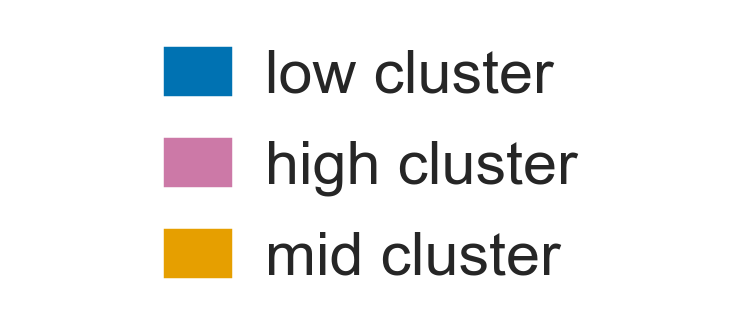

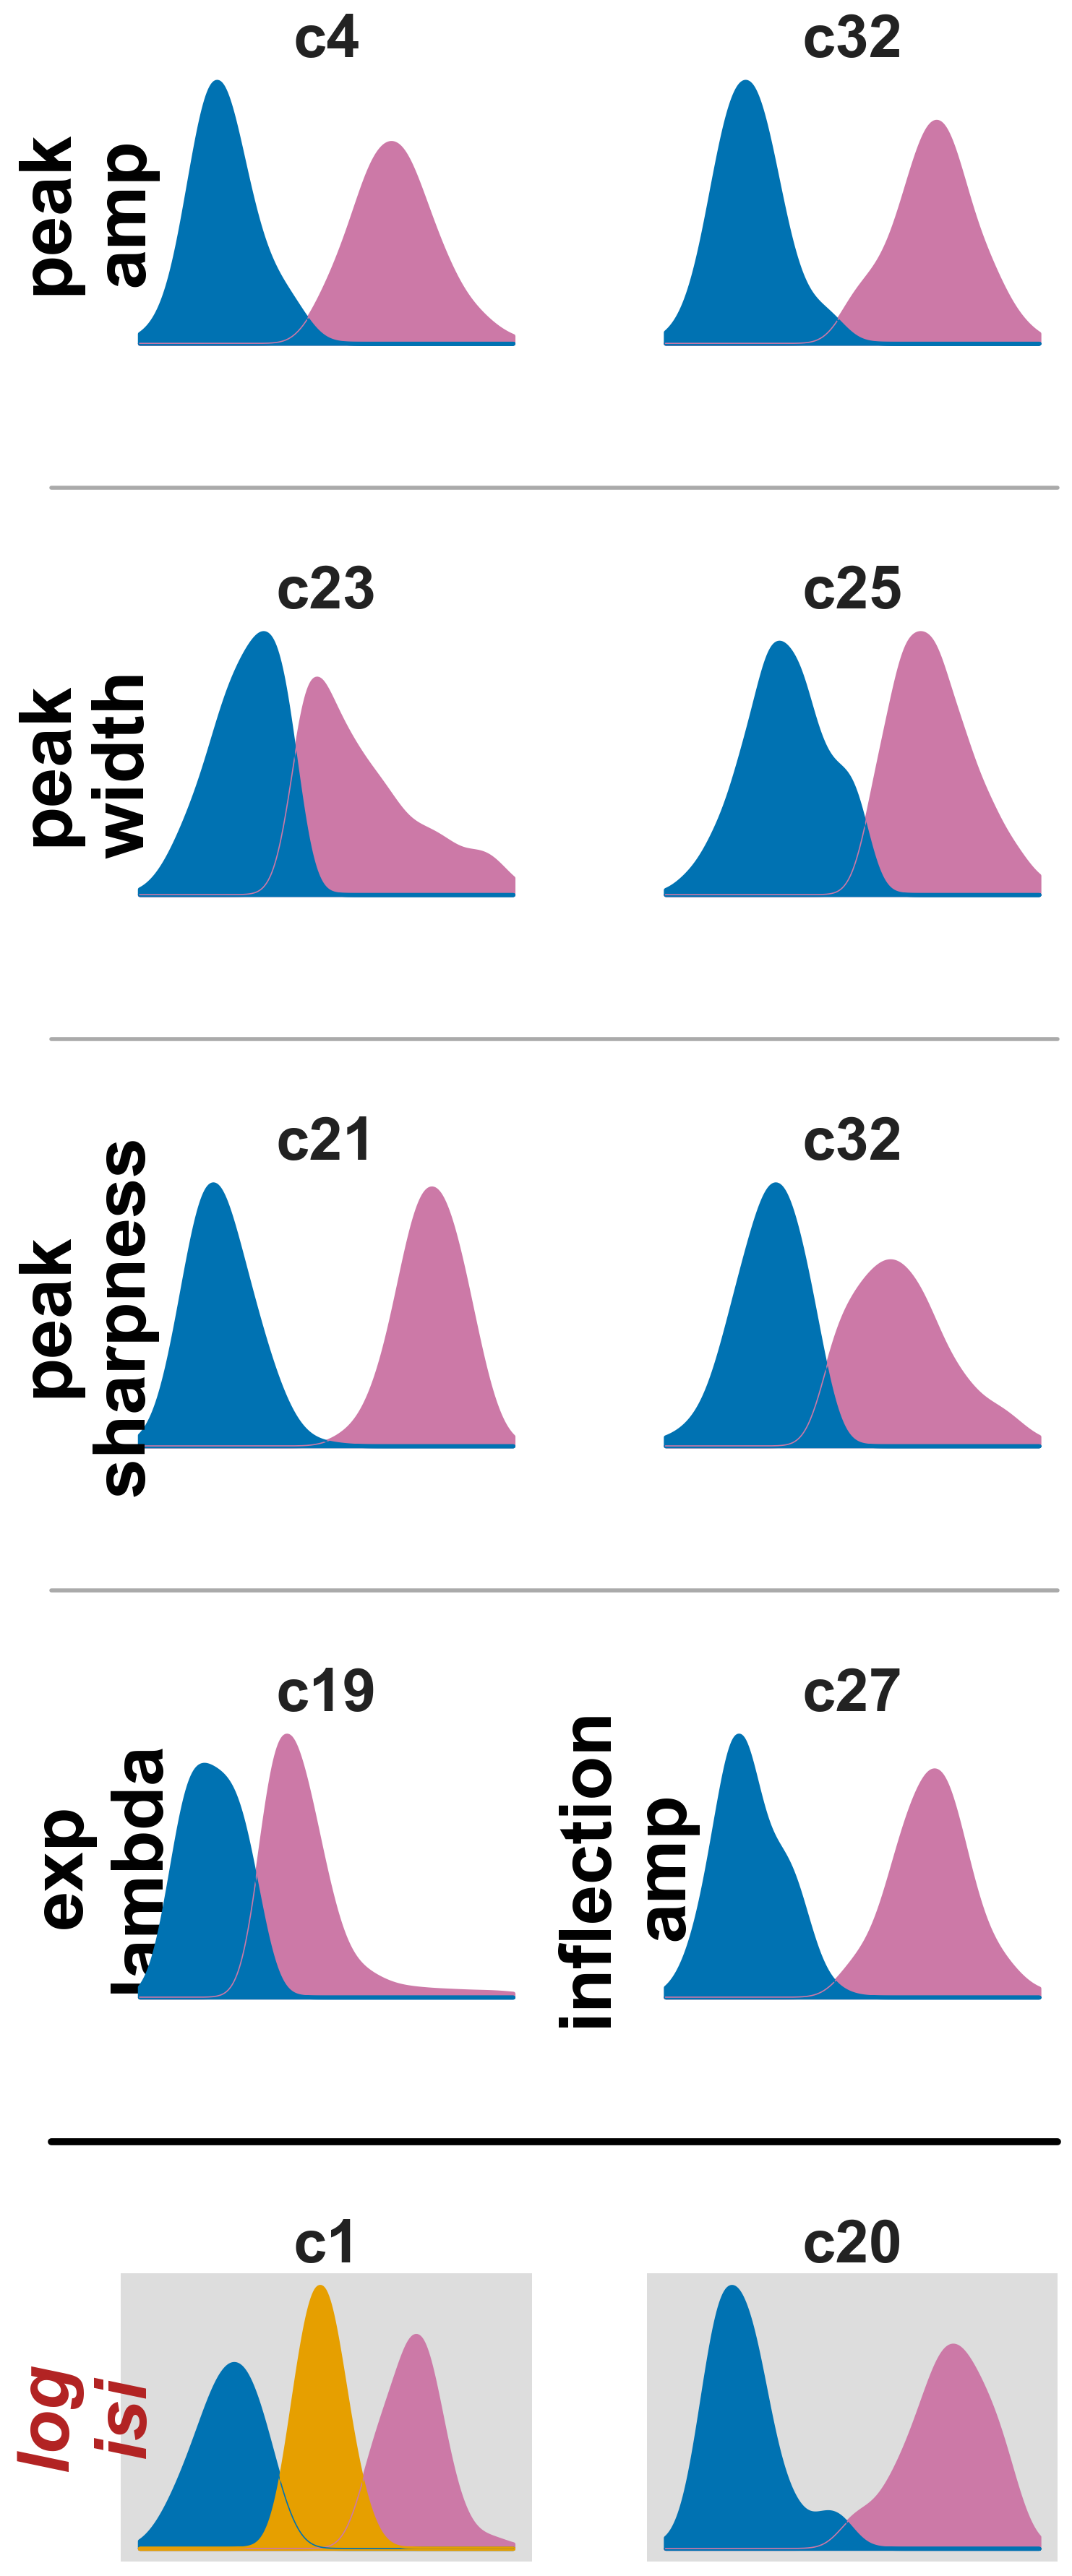

In [3]:
plot_fig4b(data)

## The clusters are different spike shapes

Separate bumps in a feature's distribution only matter if the spikes in each cluster actually look different. Averaging the spikes within each cluster shows that, in a subset of neurons, the cluster-average waveforms are visibly distinct (Fig. 4C): the same neuron fires taller and shorter spikes, or sharper and blunter ones.

Below: the average waveform of each cluster (line) with its standard deviation (shading), for the example cells in Fig. 4C.

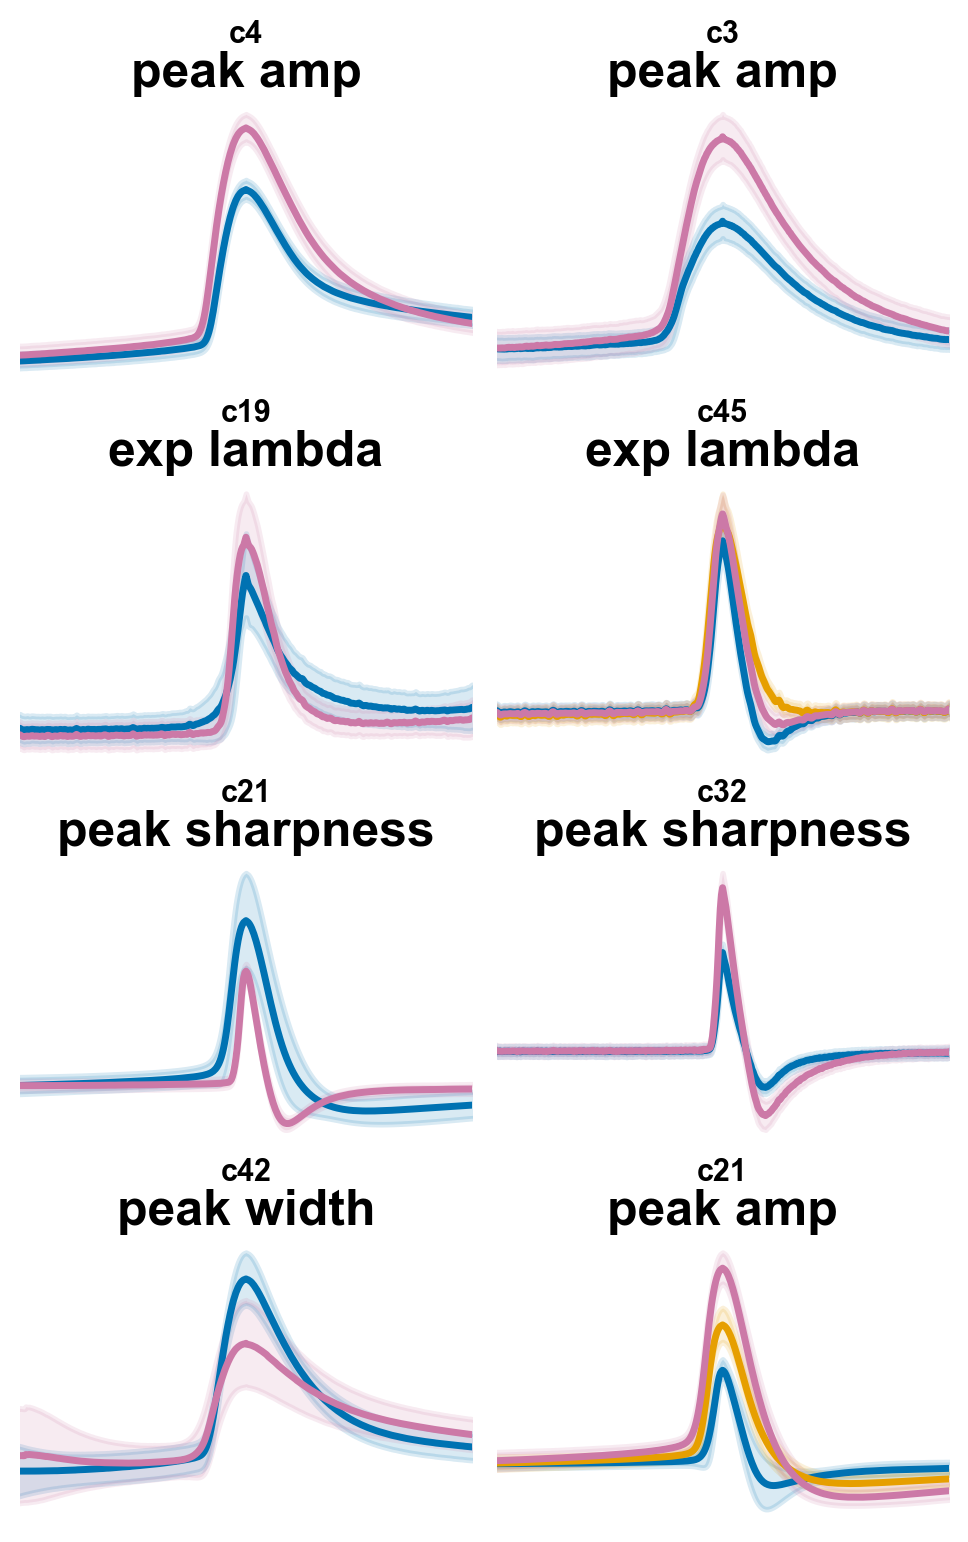

In [4]:
plot_fig4c(data)

## Waveform clusters are not just firing rate

Neurons also had multimodal ISI distributions (34 of 40 cells, 85%), for example when a neuron alternates between bursts and single spikes. One explanation for the waveform clusters could be that short-ISI spikes simply look different from long-ISI spikes. They do not: a spike's waveform cluster did not predict whether it had a short or long ISI (median η² = 0.013 across cells; Supp. Fig. 9). Waveform state and firing rate vary independently within a cell.

## Waveform states change over the recording

The clusters were not randomly interleaved in time. In most cell by feature pairs (88 of 103), cluster membership was correlated with time in the recording: a neuron might produce low peak amplitude spikes during one part of a recording and high peak amplitude spikes during another. In many cells these shifts were abrupt enough to pinpoint when the neuron switched states (Supp. Fig. 11). No recording metadata (cell type, depth, patch configuration and so on) predicted how separated the clusters were, how much they drifted over time, or which features clustered.

## Explore a cell

Pick a neuron and one of its clustered features to see its full cluster report, as produced for every cell in the paper's analyses:
1. **Spike waveforms by cluster**: example single spikes from each cluster, with the average over all of that cluster's spikes;
2. **Cluster-average comparison**: each pair of clusters overlaid in absolute amplitude, scaled to the same maximum (nRMSE, the overall waveform difference) and z-scored (cosine similarity, the difference in shape alone);
3. **Over time**: when in the recording each cluster's spikes occur, and the Spearman correlation between spike time and cluster;
4. **Transitions**: how likely the next spike is to fall in each cluster, given the current spike's cluster;
5. **All features by cluster**: how every other spike feature differs between these clusters;
6. **Statistics**: whether the clustered feature differs between clusters.

Only neurons with at least one clustered feature are listed.

(Static snapshot. Run this cell to use the interactive controls.)


c21 (putative PC, 12556 spikes): Peak sharpness splits into 2 clusters (low: 10652, high: 1904 spikes)

1. Spike waveforms by cluster


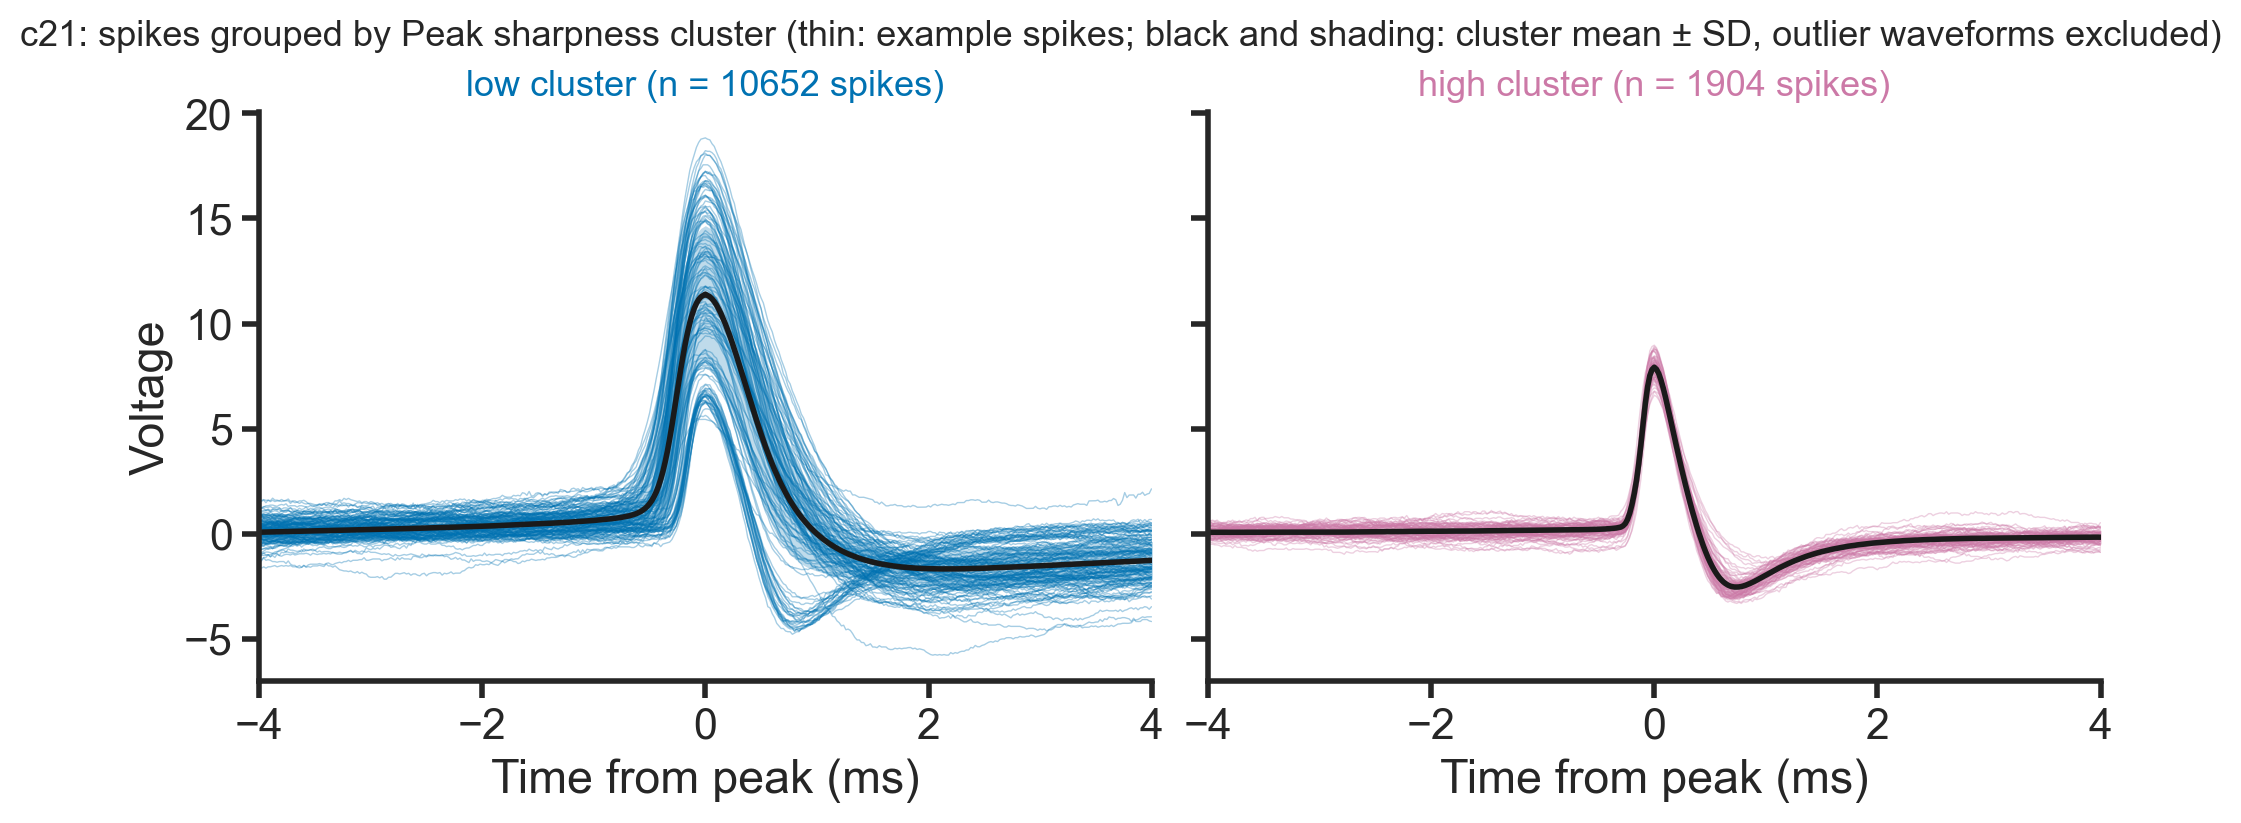

2. How different are the cluster-average waveforms?


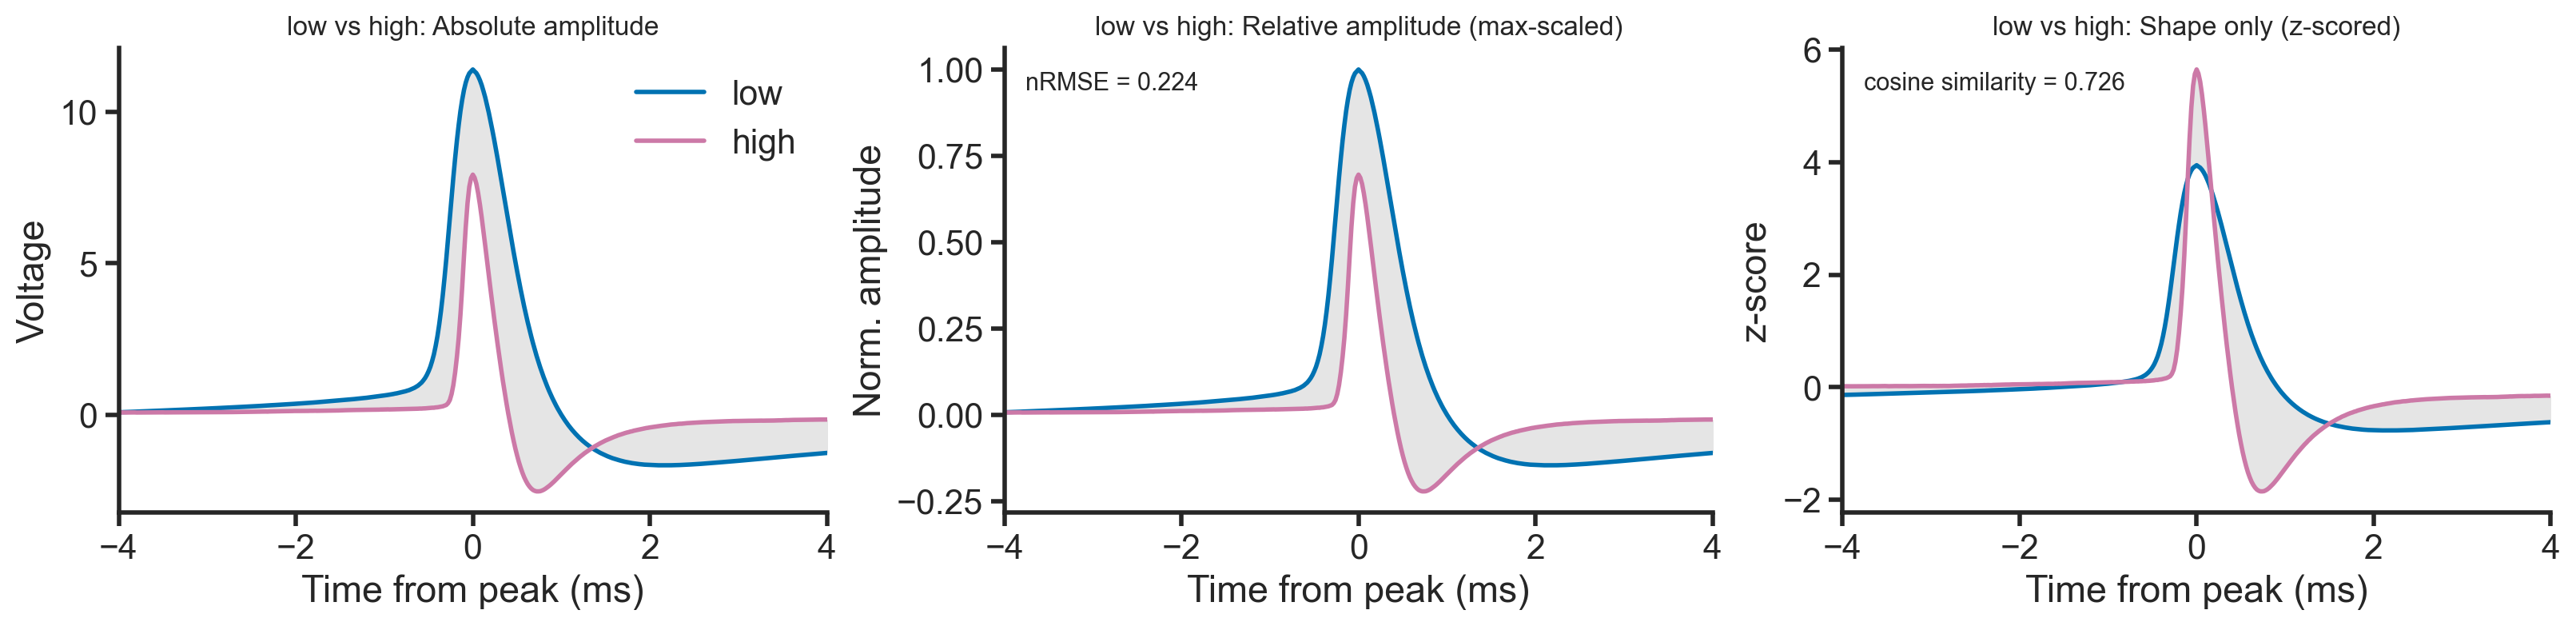

3. When in the recording does each cluster occur? (top: every spike; bottom: firing rate per cluster)
   Spearman ρ between spike time and cluster label = -0.62 (p < 1e-300)


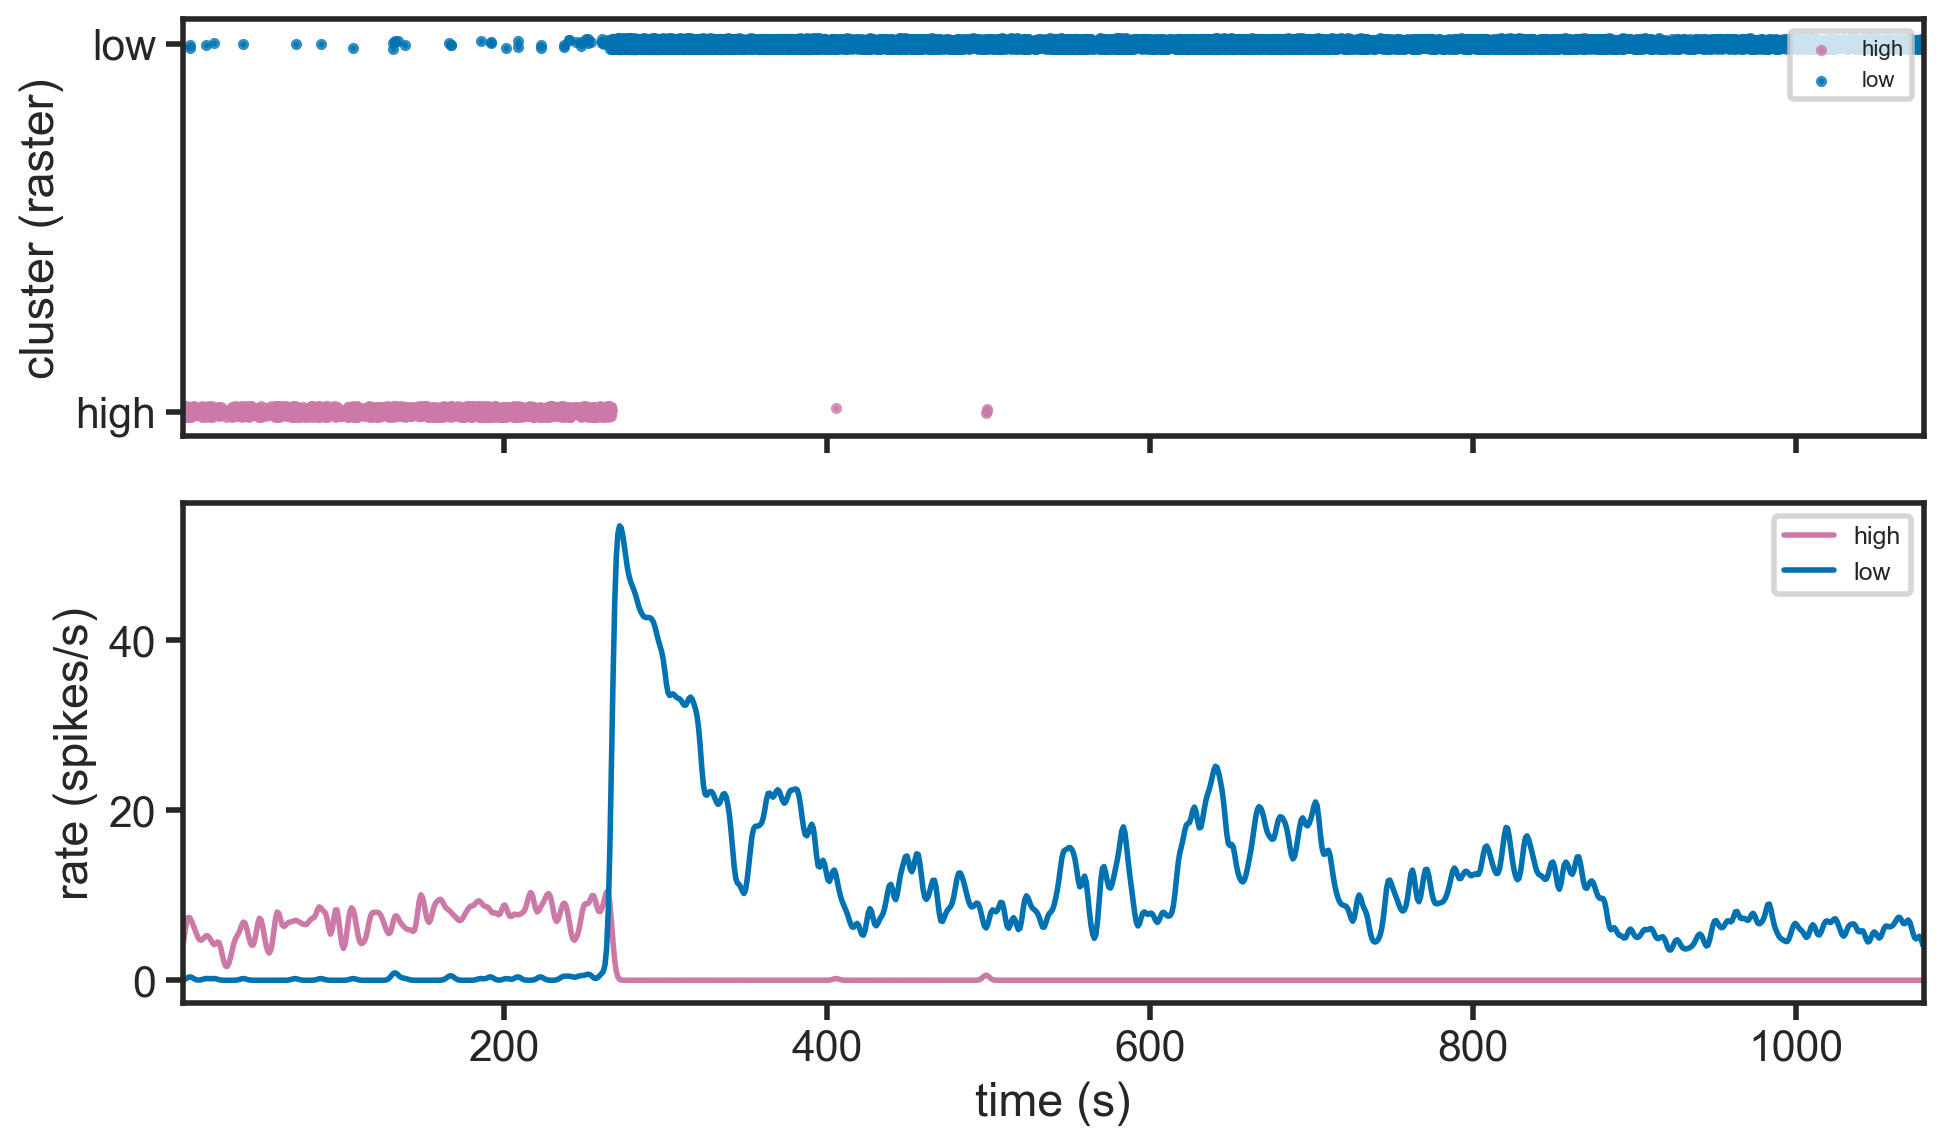

4. Does a spike's cluster predict the next spike's cluster?


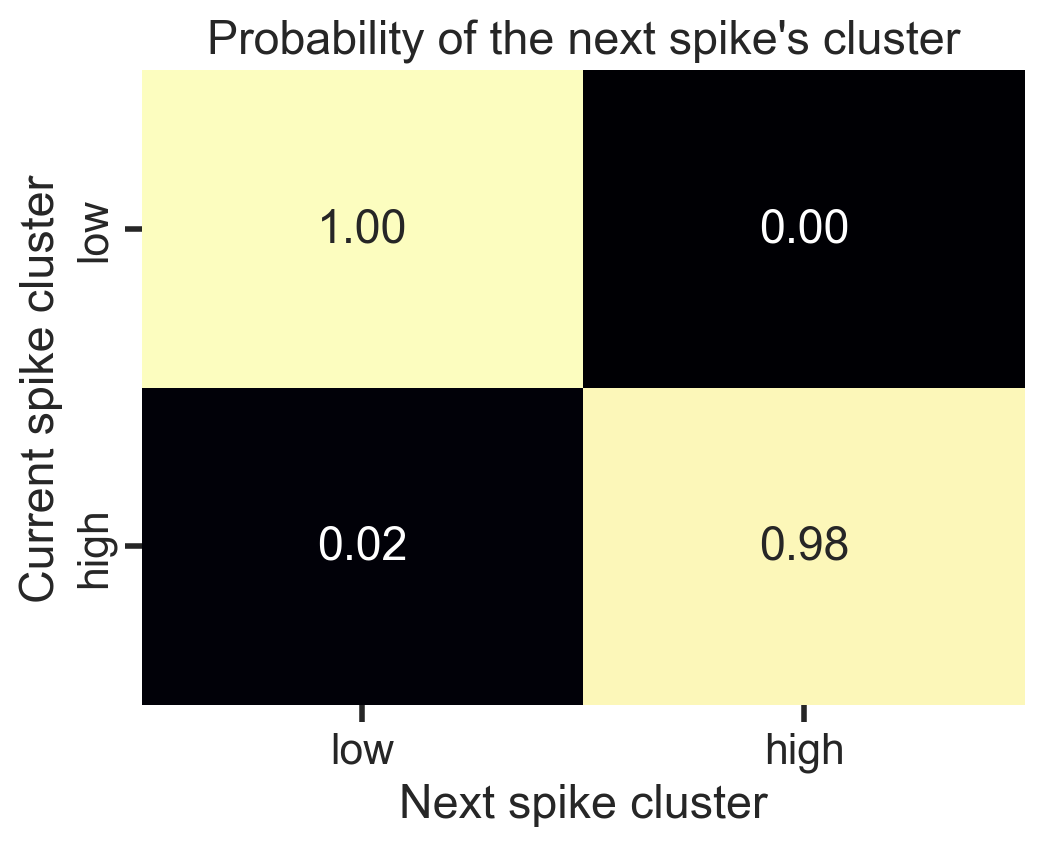

5. All spike features, split by these clusters


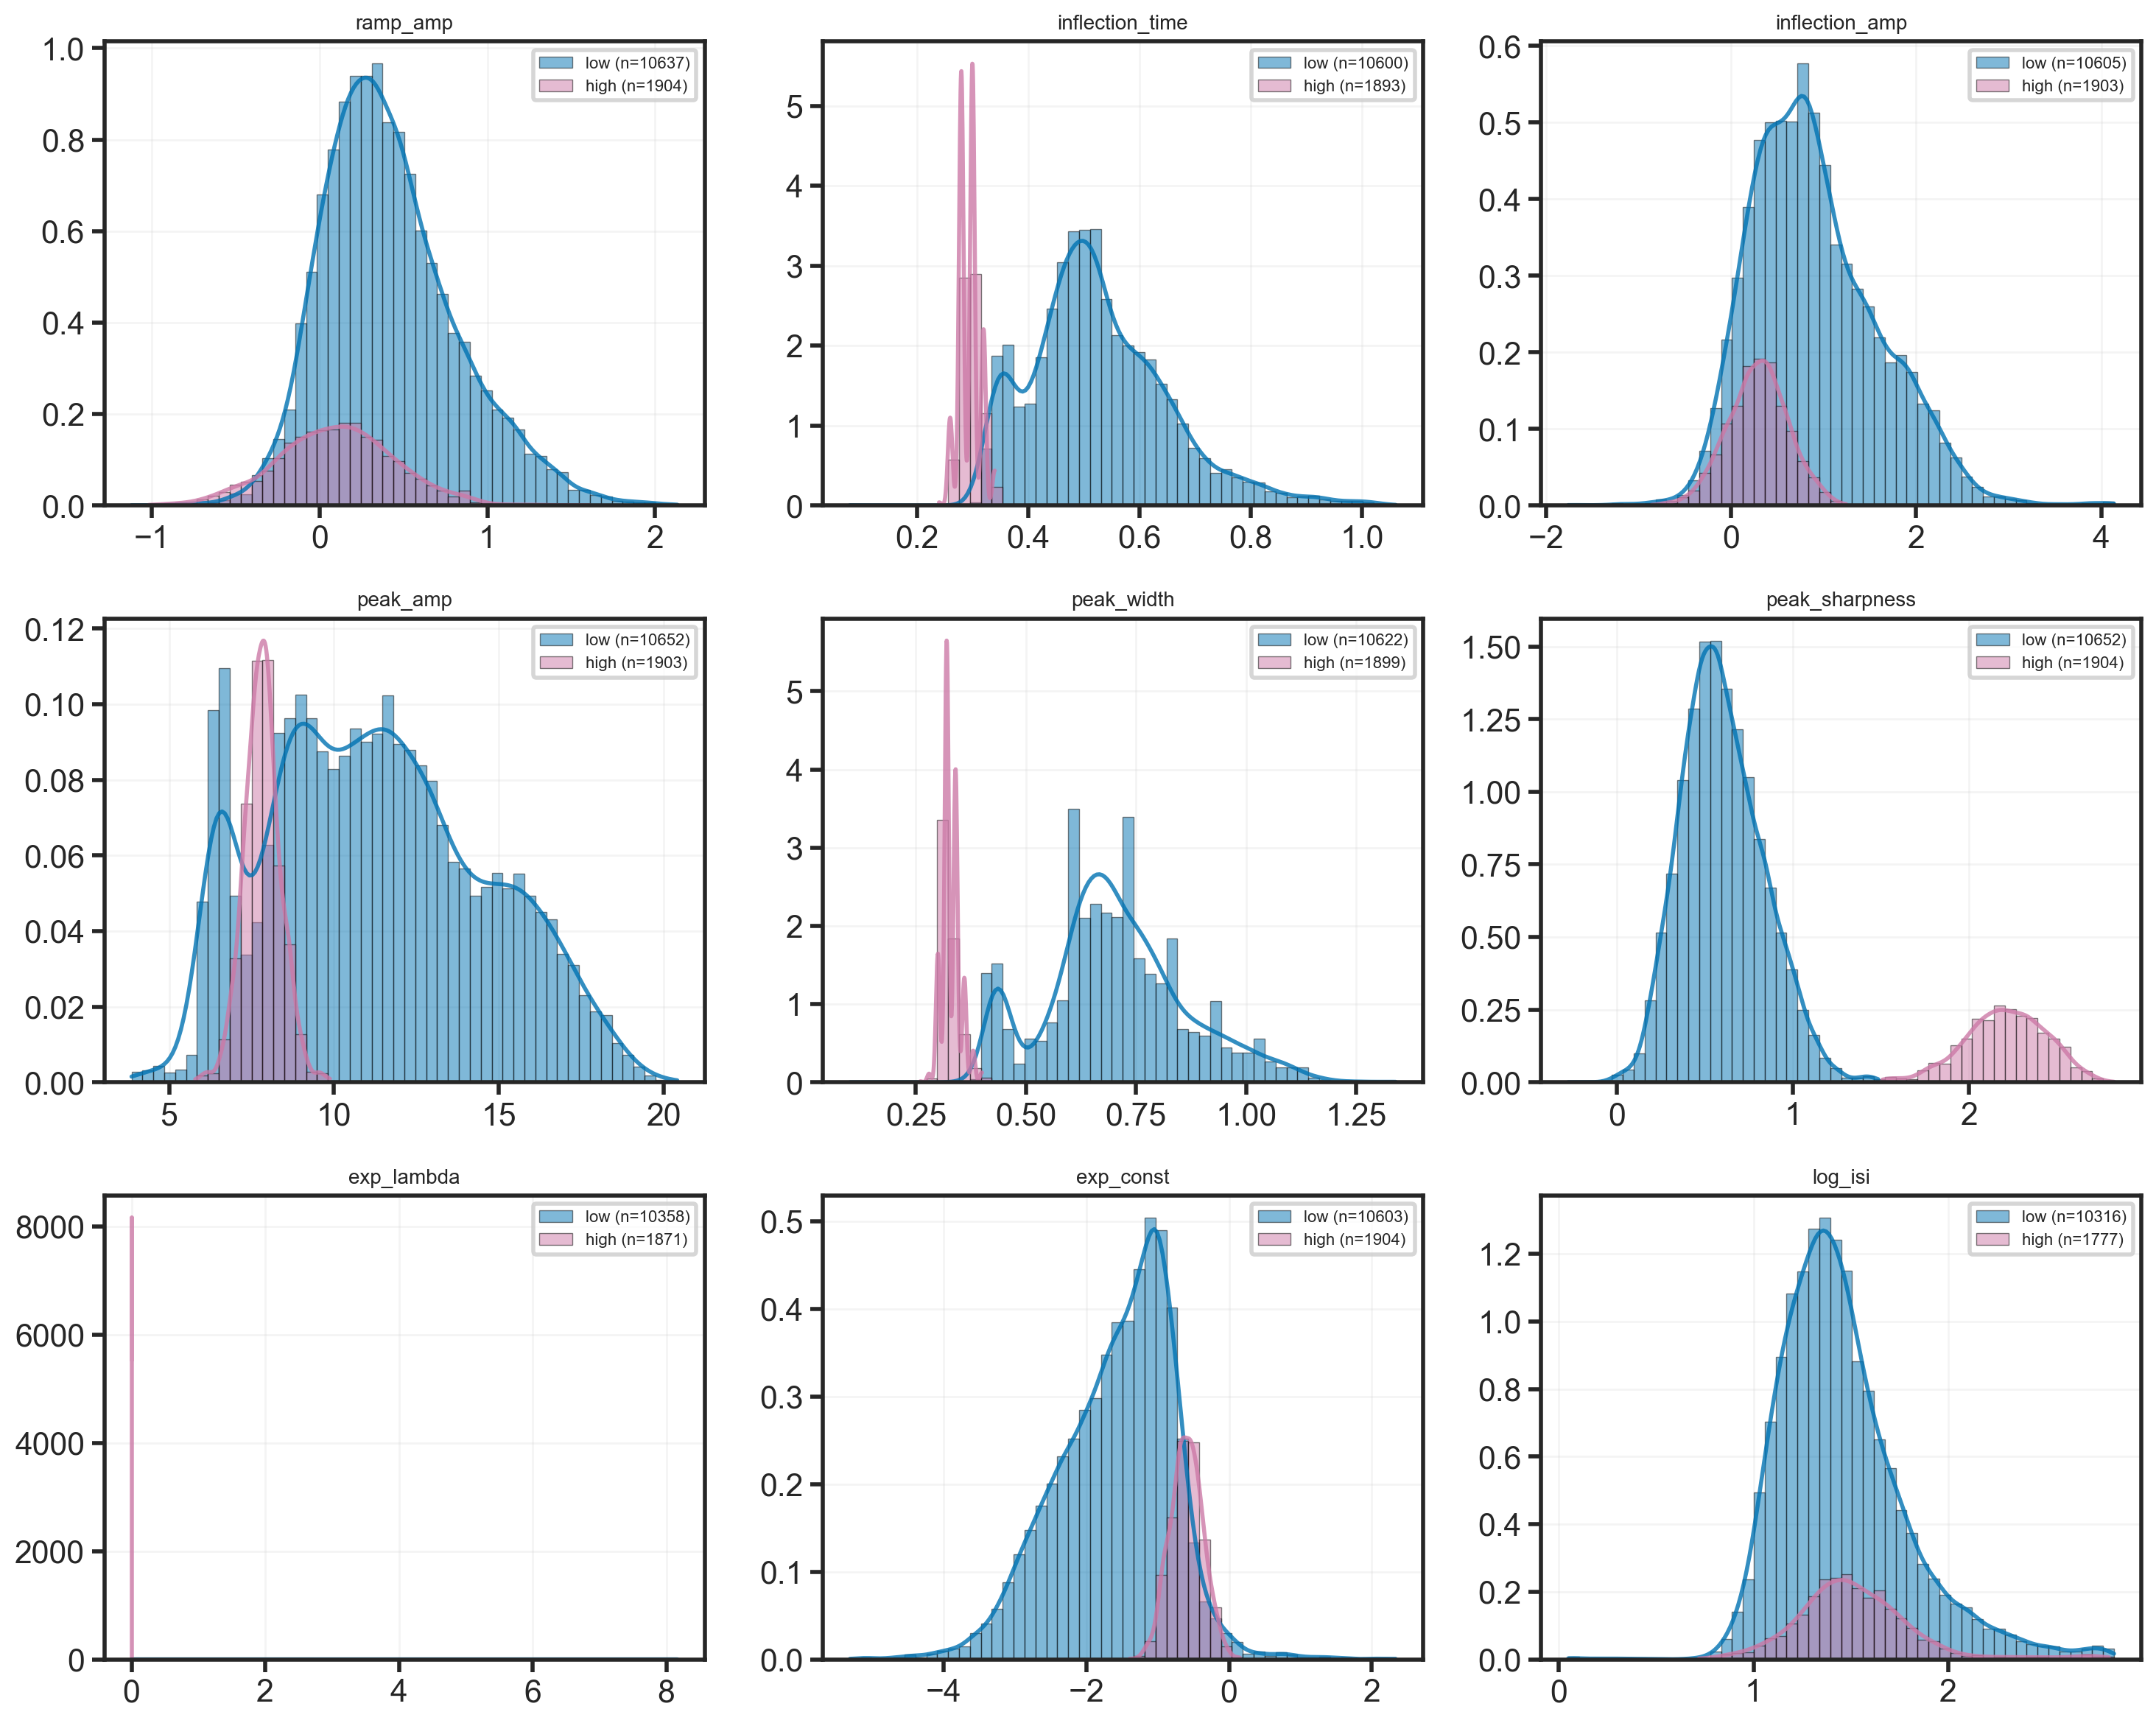

6. Is Peak sharpness different between clusters?
  Mann-Whitney U: p < 1e-300 ***, η² = 0.859 (Very Large)


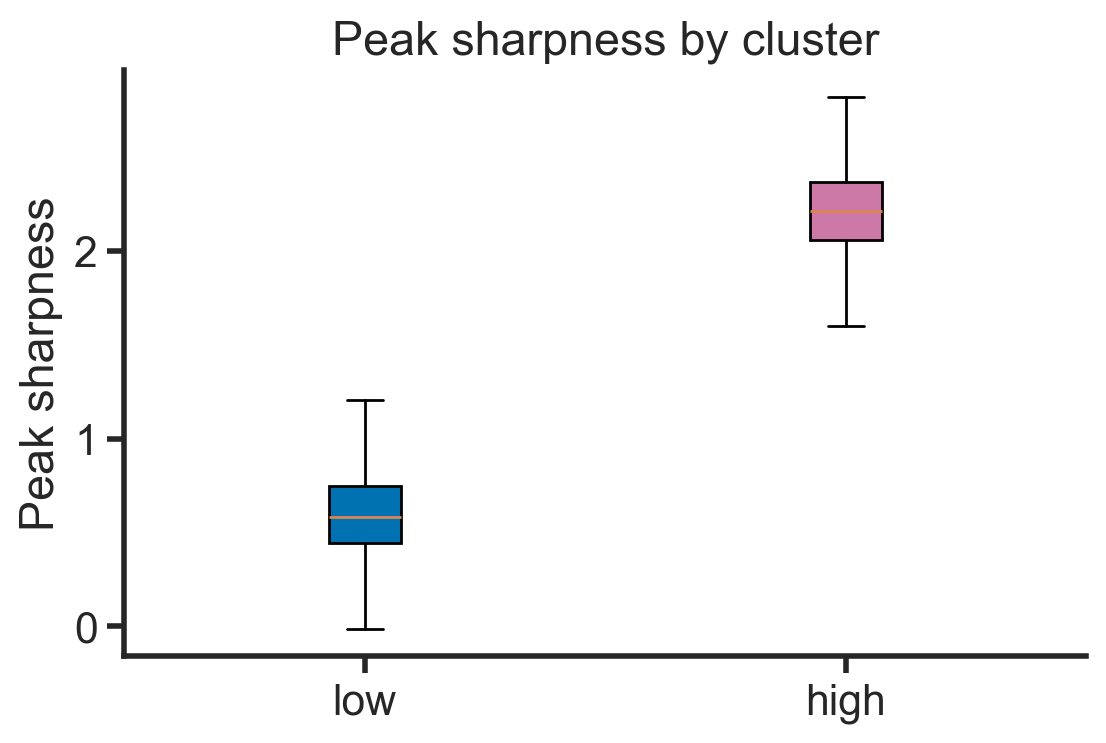

In [5]:
cluster_report_explorer(data, cell=21, feature='peak_sharpness')